Analiza skupa podataka (Animals 10)

In [16]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

sys.path.insert(0, str('src'))
from dataset import LABEL_MAP, CLASSES

DATA_DIR = Path('raw-img')

print('Python path OK')
print(f'Data dir postoji: {DATA_DIR.exists()}')
print(f'Klase: {CLASSES}')

Python path OK
Data dir postoji: True
Klase: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


Učitavanje i validacija

In [10]:
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []
korumpirane = []

for it_name, en_name in LABEL_MAP.items():
    class_dir = DATA_DIR / it_name
    if not class_dir.exists():
        print(f'  [NEDOSTAJE] {class_dir}')
        continue
    imgs = [p for p in class_dir.iterdir() if p.suffix.lower() in VALID_EXT]
    for p in imgs:
        try:
            img = Image.open(p)
            w, h = img.size
            mode = img.mode
            img.close()
            records.append({
                'klasa': en_name,
                'folder': it_name,
                'fajl': p.name,
                'sirina': w,
                'visina': h,
                'aspekt': round(w/h, 2),
                'mod': mode,
                'putanja': str(p)
            })
        except Exception as e:
            korumpirane.append((str(p), str(e)))

df = pd.DataFrame(records)
print(f'Ukupno validnih slika : {len(df)}')
print(f'Korumpirani fajlovi   : {len(korumpirane)}')
print(f'\nPrvih 5 redova:')
df.head()

Ukupno validnih slika : 26178
Korumpirani fajlovi   : 0

Prvih 5 redova:


,klasa,folder,fajl,sirina,visina,aspekt,mod,putanja
0,dog,cane,OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg,300,225,1.33,RGB,raw-img\cane\OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
1,dog,cane,OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg,300,214,1.40,RGB,raw-img\cane\OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg
2,dog,cane,OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg,153,300,0.51,RGB,raw-img\cane\OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg
3,dog,cane,OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg,300,225,1.33,RGB,raw-img\cane\OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg
4,dog,cane,OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg,300,225,1.33,RGB,raw-img\cane\OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg


In [ ]:
print('Nedostajuće vrednosti po koloni:')
print(df.isnull().sum())
print(f'\nBroj unikatnih klasa: {df["klasa"].nunique()}')
print(f'Formati slika (mod): {df["mod"].value_counts().to_dict()}')

non_rgb = df[df['mod'] != 'RGB']
if len(non_rgb) > 0:
    print(f'\nSlike koje nisu u RGB formatu: {len(non_rgb)} (bice konvertovane automatski)')
    print(non_rgb[['klasa','fajl','mod']].head())
else:
    print('\nSve slike su u RGB formatu.')

Nedostajuce vrednosti po koloni:
klasa      0
folder     0
fajl       0
sirina     0
visina     0
aspekt     0
mod        0
putanja    0
dtype: int64

Broj unikatnih klasa: 10
Formati slika (mod): {'RGB': 26127, 'RGBA': 49, 'L': 1, 'CMYK': 1}

Slike koje nisu u RGB formatu: 51 (bice konvertovane automatski)
         klasa                                               fajl   mod
7529  elephant  e835b50620f0013ed1584d05fb1d4e9fe777ead218ac10...  RGBA
7530  elephant  e835b50620f0073ed1584d05fb1d4e9fe777ead218ac10...  RGBA
7531  elephant  e835b50620f7083ed1584d05fb1d4e9fe777ead218ac10...  RGBA
7532  elephant  e835b50620f7093ed1584d05fb1d4e9fe777ead218ac10...  RGBA
7565  elephant  e83db7072afd013ed1584d05fb1d4e9fe777ead218ac10...     L


Distribucija klasa

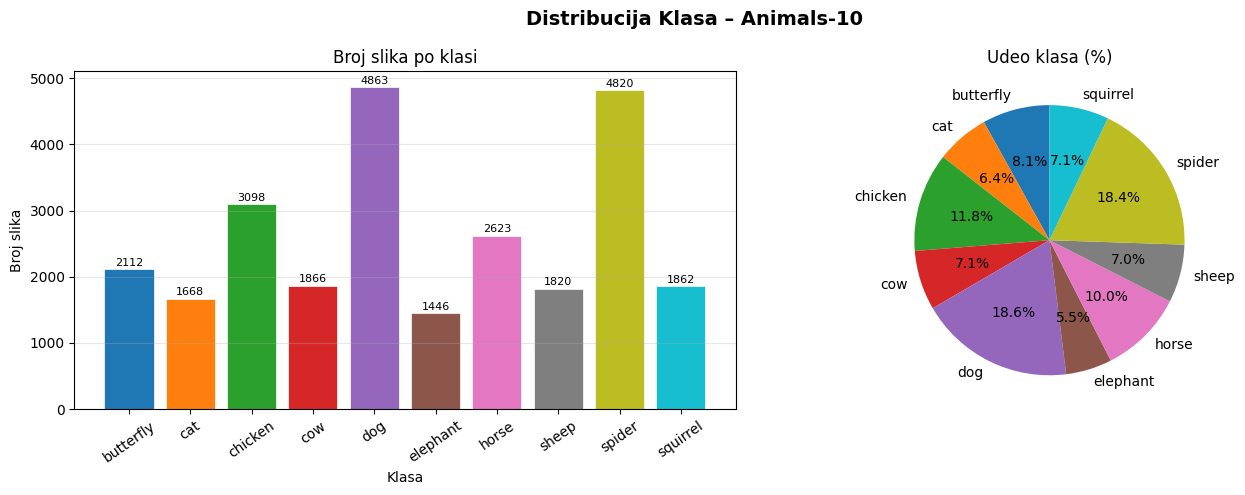


Statistike distribucije:
  Min: 1446 (elephant)
  Max: 4863 (dog)
  Prosek: 2617.8
  Std: 1266.0
  Imbalance ratio: 3.36x


In [ ]:
counts = df['klasa'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucija Klasa – Animals-10', fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Broj slika po klasi')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj slika')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(v), ha='center', va='bottom', fontsize=8)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Udeo klasa (%)')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nStatistike distribucije:')
print(f'  Min: {counts.min()} ({counts.idxmin()})')
print(f'  Max: {counts.max()} ({counts.idxmax()})')
print(f'  Prosek: {counts.mean():.1f}')
print(f'  Std: {counts.std():.1f}')
print(f'  Imbalance ratio: {counts.max()/counts.min():.2f}x')

Analiza dimenzija slika

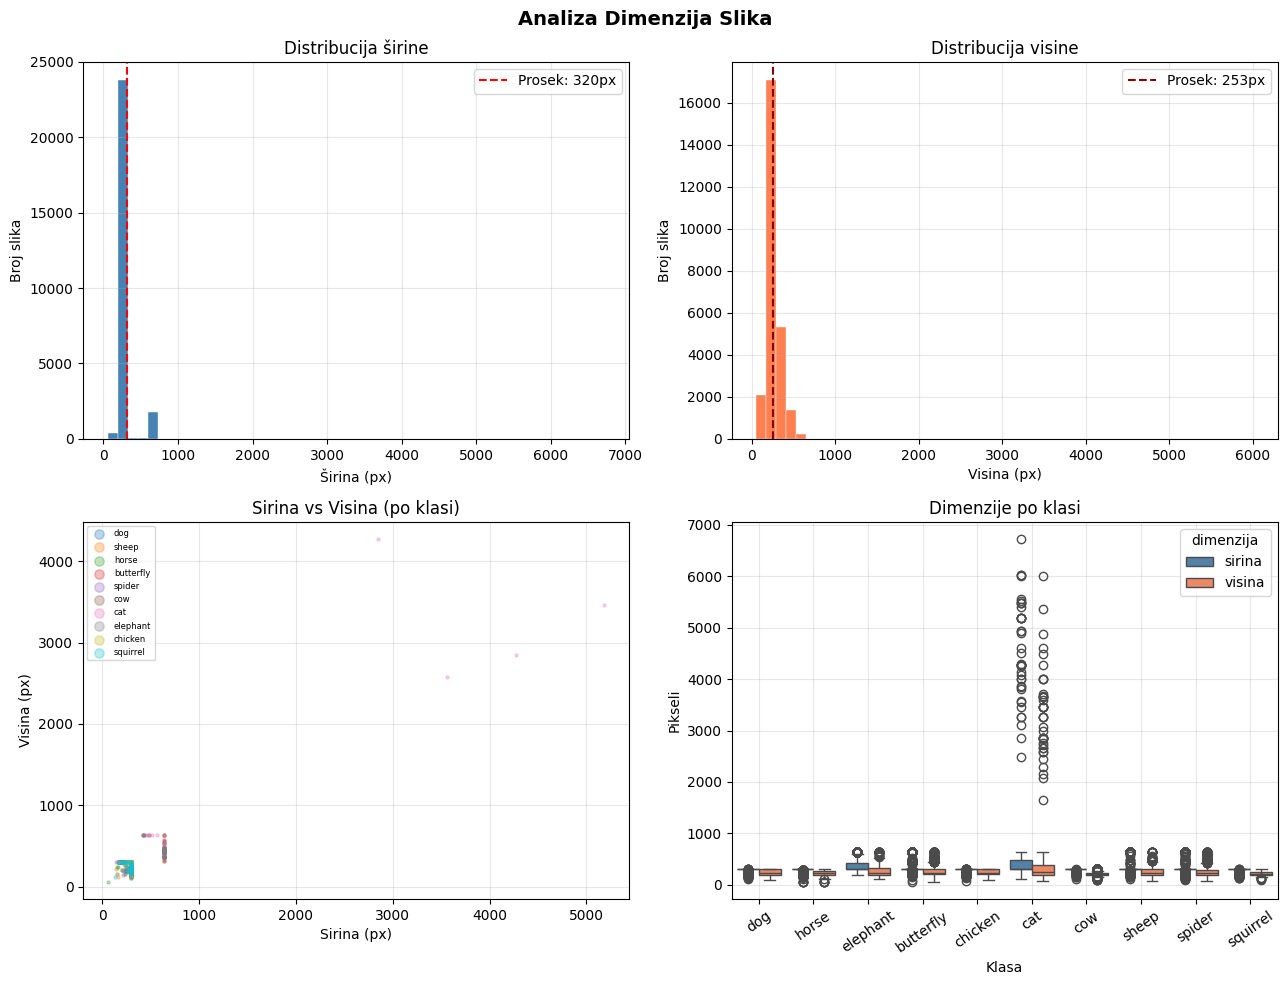

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Analiza Dimenzija Slika', fontsize=14, fontweight='bold')


axes[0,0].hist(df['sirina'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0,0].axvline(df['sirina'].mean(), color='red', linestyle='--', label=f'Prosek: {df["sirina"].mean():.0f}px')
axes[0,0].set_title('Distribucija širine')
axes[0,0].set_xlabel('Širina (px)')
axes[0,0].set_ylabel('Broj slika')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)


axes[0,1].hist(df['visina'], bins=50, color='coral', edgecolor='white', linewidth=0.3)
axes[0,1].axvline(df['visina'].mean(), color='darkred', linestyle='--', label=f'Prosek: {df["visina"].mean():.0f}px')
axes[0,1].set_title('Distribucija visine')
axes[0,1].set_xlabel('Visina (px)')
axes[0,1].set_ylabel('Broj slika')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

sample = df.sample(min(2000, len(df)), random_state=42)
klase = sample['klasa'].unique()
pal = plt.cm.tab10(np.linspace(0, 1, len(klase)))
for i, k in enumerate(klase):
    sub = sample[sample['klasa'] == k]
    axes[1,0].scatter(sub['sirina'], sub['visina'], alpha=0.3, s=5, color=pal[i], label=k)
axes[1,0].set_title('Širina vs Visina (po klasi)')
axes[1,0].set_xlabel('Širina (px)')
axes[1,0].set_ylabel('Visina (px)')
axes[1,0].legend(fontsize=6, markerscale=3)
axes[1,0].grid(alpha=0.3)


df_melt = df.melt(id_vars='klasa', value_vars=['sirina', 'visina'],
                  var_name='dimenzija', value_name='px')
sns.boxplot(data=df_melt, x='klasa', y='px', hue='dimenzija',
            ax=axes[1,1], palette=['steelblue','coral'])
axes[1,1].set_title('Dimenzije po klasi')
axes[1,1].set_xlabel('Klasa')
axes[1,1].set_ylabel('Pikseli')
axes[1,1].tick_params(axis='x', rotation=35)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=120, bbox_inches='tight')
plt.show()